In [1]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

In [2]:
import torch
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline
from IPython.display import display, clear_output
from PIL import Image
import os

device = "cpu"
dtype = torch.float32

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


In [3]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)

pipe = pipe.to(device)
pipe.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
BASE_STYLE = (
    "high detail, realistic textures, "
    "16:9 composition, shallow depth of field")

NEGATIVE_PROMPT = (
    "low quality, blurry, distorted, bad anatomy, extra limbs, "
    "text, watermark, logo"
)

CHAR_ANCHOR = (
    "the same robot in every scene: small bipedal service robot, rounded rectangular head, "
    "single unbroken cyan horizontal visor (no pupils, no multiple eyes), matte off-white metal body, "
    "rust on shoulders and knees, red scarf, small dent on chest plate"
)


scene_prompts = [
    f"{CHAR_ANCHOR}. Scene 1: extreme wide shot, robot is small in frame, walking alone through wasteland, no flower. {BASE_STYLE}",
    f"{CHAR_ANCHOR}. Scene 2: medium shot, robot stops and leans toward a tiny flower in rubble, one foot forward. {BASE_STYLE}",
    f"{CHAR_ANCHOR}. Scene 3: close-up, robot kneeling, hand reaching toward flower, visor reflecting the flower. {BASE_STYLE}",
    f"{CHAR_ANCHOR}. Scene 4: side profile tracking shot, robot walking away with flower tucked behind antenna, hopeful. {BASE_STYLE}",
]

Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['depth of field']


  0%|          | 0/20 [00:00<?, ?it/s]

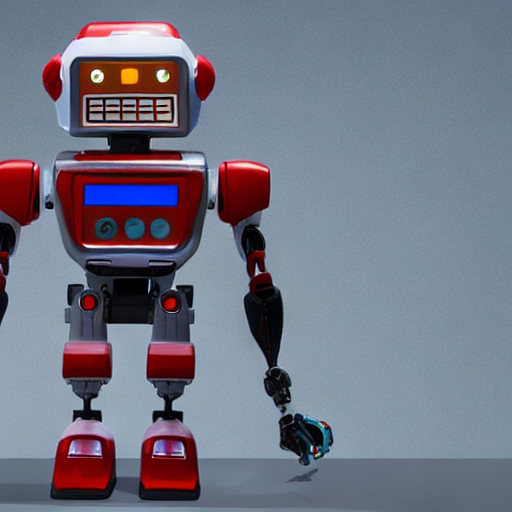

In [5]:
WIDTH, HEIGHT = 512, 512
NUM_INFERENCE_STEPS = 20
GUIDANCE_SCALE = 7.5

ref_prompt = f"{CHAR_ANCHOR}. full body, neutral pose, plain background. {BASE_STYLE}"

ref_image = pipe(
    prompt=ref_prompt,
    negative_prompt=NEGATIVE_PROMPT,
    width=WIDTH,
    height=HEIGHT,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    generator=torch.Generator(device=device).manual_seed(123),
).images[0]

display(ref_image)

In [6]:
img2img = StableDiffusionImg2ImgPipeline(**pipe.components).to(device)
img2img.enable_attention_slicing()

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_img2img.StableDiffusionImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


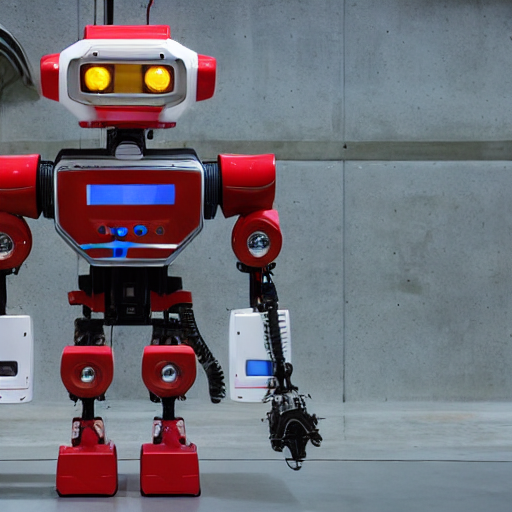

In [7]:
SEED_BASE = 42
scene_seeds = [SEED_BASE + i for i in range(len(scene_prompts))]

STRENGTH = 0.72

generated_images = []

for i, (prompt, seed) in enumerate(zip(scene_prompts, scene_seeds), 1):
    out = img2img(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        image=ref_image.resize((WIDTH, HEIGHT)),
        strength=STRENGTH,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=torch.Generator(device=device).manual_seed(seed),
    ).images[0]

    generated_images.append(out)
    clear_output(wait=True)
    display(out)

In [8]:
output_dir = os.path.join(os.getcwd(), "storyboard_outputs")
os.makedirs(output_dir, exist_ok=True)

for i, img in enumerate(generated_images, 1):
    img.save(os.path.join(output_dir, f"scene_{i}.png"))

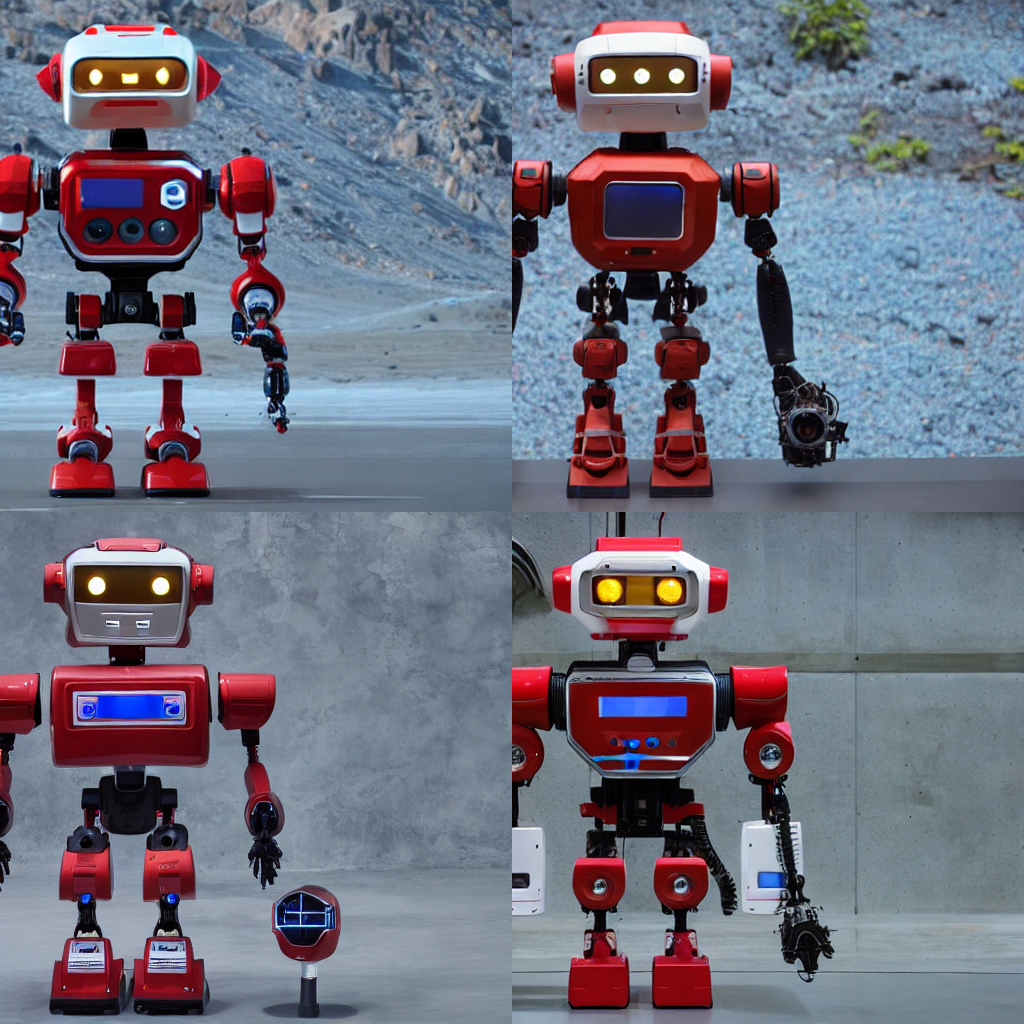

In [9]:
storyboard = Image.new("RGB", (WIDTH * 2, HEIGHT * 2))

storyboard.paste(generated_images[0], (0, 0))
storyboard.paste(generated_images[1], (WIDTH, 0))
storyboard.paste(generated_images[2], (0, HEIGHT))
storyboard.paste(generated_images[3], (WIDTH, HEIGHT))

storyboard_path = os.path.join(output_dir, "storyboard_2x2.png")
storyboard.save(storyboard_path)

display(storyboard)